# YouTube + Google Meet QoE: 6 vs. 10 Mbps

Comparison of synchronized 15-second dual-application experiments using a shared **100 ms / pfifo / 50-packet** bottleneck. YouTube QoE comes from Stats for Nerds and the video element; Google Meet QoE comes from receiver-side WebRTC `inbound-rtp` statistics.

In [1]:
from pathlib import Path
import json
import math
import subprocess

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

base_candidates = [
    Path('youtube_google_meet_100ms_pfifo/results'),
    Path('experiments/youtube_google_meet_100ms_pfifo/results'),
]
RESULTS_ROOT = next((p.resolve() for p in base_candidates if p.is_dir()), None)
if RESULTS_ROOT is None:
    raise FileNotFoundError('Could not locate YouTube + Google Meet results')

TIERS = (6, 10)
COLORS = {6: '#1f78b4', 10: '#e31a1c'}

def load_jsonl(path):
    with path.open() as handle:
        return [json.loads(line) for line in handle if line.strip()]

runs = {}
for tier in TIERS:
    directory = RESULTS_ROOT / f'{tier}mbps'
    youtube = load_jsonl(directory / 'youtube_stats.jsonl')
    meet = load_jsonl(directory / 'google_meet_stats.jsonl')
    shaping = json.loads((directory / 'shaping.json').read_text())['bottleneck_state']
    runs[tier] = {'directory': directory, 'youtube': youtube, 'meet': meet, 'shaping': shaping}

summary_rows = []
for tier, run in runs.items():
    ys = [row['stats'] for row in run['youtube']]
    ms = [row['stats'] for row in run['meet']]
    rates = [s['inbound_bitrate_mbps'] for s in ms if s.get('inbound_bitrate_mbps') is not None]
    summary_rows.append({
        'tier': f'{tier} Mbps',
        'YouTube final resolution': ys[-1]['resolution'],
        'YouTube dropped frames': (ys[-1].get('dropped_video_frames', 0) or 0) - (ys[0].get('dropped_video_frames', 0) or 0),
        'Meet final resolution': ms[-1]['resolution'],
        'Meet avg video Mbps': sum(rates) / len(rates),
        'Meet dropped frames': ms[-1]['frames_dropped'] - ms[0]['frames_dropped'],
        'Meet new freezes': ms[-1]['freeze_count'] - ms[0]['freeze_count'],
        'Meet freeze duration (s)': ms[-1]['total_freezes_duration_seconds'] - ms[0]['total_freezes_duration_seconds'],
    })

display(pd.DataFrame(summary_rows).set_index('tier').round(3))
plt.style.use('seaborn-v0_8-whitegrid')

,YouTube final resolution,YouTube dropped frames,Meet final resolution,Meet avg video Mbps,Meet dropped frames,Meet new freezes,Meet freeze duration (s)
tier,,,,,,,
6 Mbps,854x480,0,480x270,0.070,4,6,6.890
10 Mbps,854x480,0,960x540,0.149,68,1,0.297


## Shared bottleneck traffic

Wire-rate download traffic is calculated from each shared PCAP over the synchronized QoE window. This validates what both applications received together, rather than relying only on the requested configuration.

,download (MiB),average wire rate (Mbps),peak 1-second rate (Mbps)
tier,,,
6 Mbps,9.970,5.901,5.985
10 Mbps,16.278,9.588,10.009


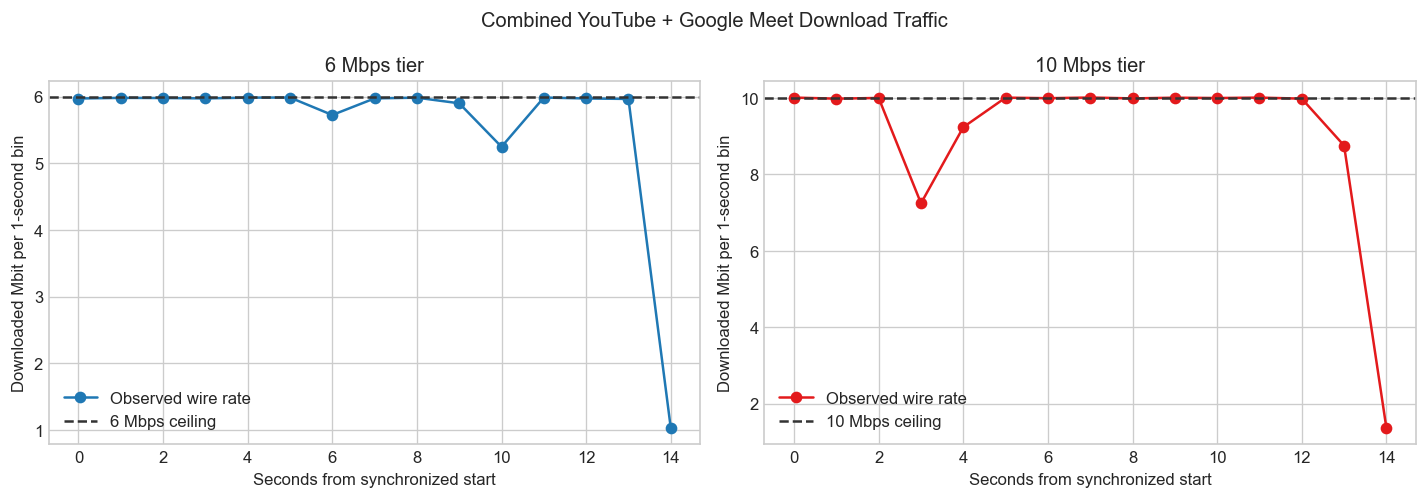

In [2]:
CLIENT_IP = '172.16.1.1'
wire_rates = {}
traffic_rows = []
for tier, run in runs.items():
    window_start = min(run['youtube'][0]['timestamp'], run['meet'][0]['timestamp'])
    window_end = max(run['youtube'][-1]['timestamp'], run['meet'][-1]['timestamp'])
    duration = window_end - window_start
    pcap = next(run['directory'].glob('*.pcap'))
    output = subprocess.run(
        ['tshark', '-r', str(pcap), '-Y', f'ip.dst == {CLIENT_IP}', '-T', 'fields',
         '-e', 'frame.time_epoch', '-e', 'frame.len'],
        check=True, capture_output=True, text=True,
    ).stdout
    bins = {}
    total_bytes = 0
    for line in output.splitlines():
        fields = line.split('\t')
        if len(fields) < 2 or not fields[0] or not fields[1]:
            continue
        timestamp = float(fields[0])
        frame_bytes = int(fields[1].split(',')[0])
        if window_start <= timestamp <= window_end:
            second = int(timestamp - window_start)
            bins[second] = bins.get(second, 0) + frame_bytes
            total_bytes += frame_bytes
    rates = [bins.get(i, 0) * 8 / 1_000_000 for i in range(max(1, math.ceil(duration)))]
    wire_rates[tier] = rates
    traffic_rows.append({
        'tier': f'{tier} Mbps',
        'download (MiB)': total_bytes / 2**20,
        'average wire rate (Mbps)': total_bytes * 8 / duration / 1_000_000,
        'peak 1-second rate (Mbps)': max(rates),
    })

display(pd.DataFrame(traffic_rows).set_index('tier').round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=120, sharey=False)
for ax, tier in zip(axes, TIERS):
    rates = wire_rates[tier]
    ax.plot(range(len(rates)), rates, marker='o', color=COLORS[tier], label='Observed wire rate')
    ax.axhline(tier, color='#333333', linestyle='--', label=f'{tier} Mbps ceiling')
    ax.set(title=f'{tier} Mbps tier', xlabel='Seconds from synchronized start', ylabel='Downloaded Mbit per 1-second bin')
    ax.legend()
fig.suptitle('Combined YouTube + Google Meet Download Traffic')
plt.tight_layout()
plt.show()

## YouTube playback QoE

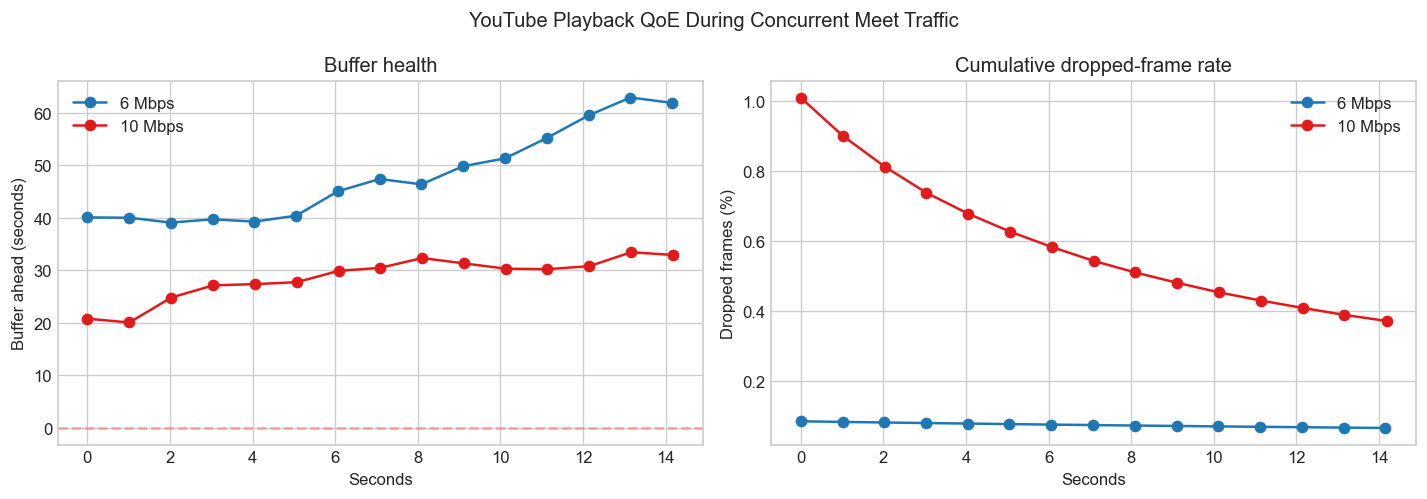

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=120)
for tier, run in runs.items():
    rows = run['youtube']
    start = rows[0]['timestamp']
    seconds = [row['timestamp'] - start for row in rows]
    buffer_ahead = [row['stats'].get('buffer_ahead_secs', 0) or 0 for row in rows]
    dropped_pct = [
        100 * (row['stats'].get('dropped_video_frames', 0) or 0)
        / max(1, row['stats'].get('total_video_frames', 0) or 0)
        for row in rows
    ]
    axes[0].plot(seconds, buffer_ahead, marker='o', color=COLORS[tier], label=f'{tier} Mbps')
    axes[1].plot(seconds, dropped_pct, marker='o', color=COLORS[tier], label=f'{tier} Mbps')
axes[0].axhline(0, color='#ff7f7f', linestyle='--', alpha=.7)
axes[0].set(title='Buffer health', xlabel='Seconds', ylabel='Buffer ahead (seconds)')
axes[1].set(title='Cumulative dropped-frame rate', xlabel='Seconds', ylabel='Dropped frames (%)')
for ax in axes:
    ax.legend()
fig.suptitle('YouTube Playback QoE During Concurrent Meet Traffic')
plt.tight_layout()
plt.show()

## Google Meet receiver network QoE

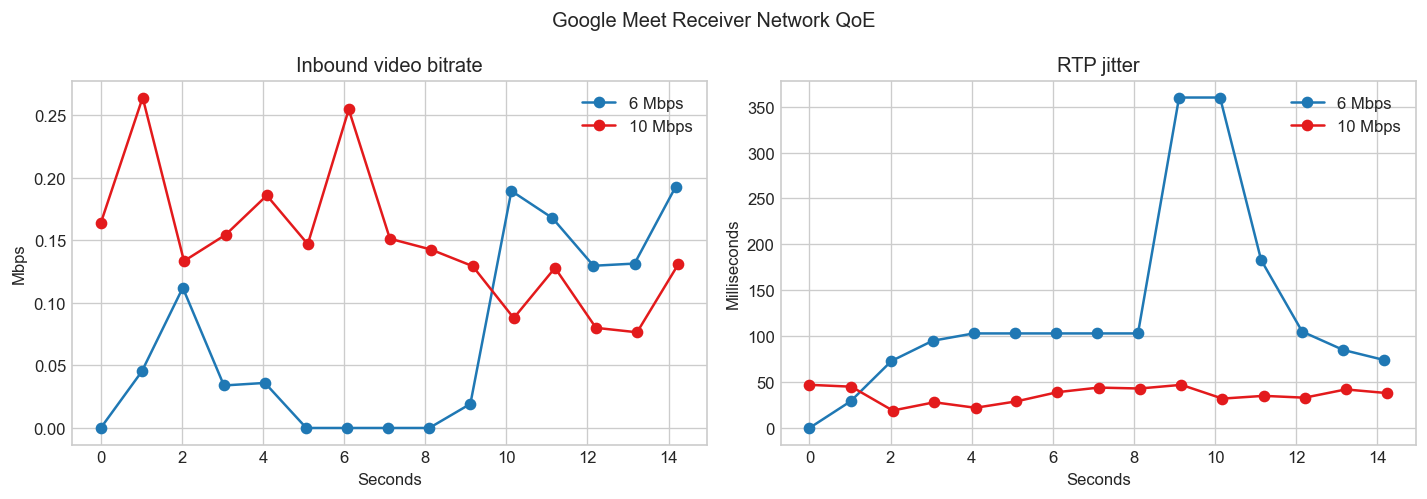

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=120)
for tier, run in runs.items():
    rows = run['meet']
    start = rows[0]['timestamp']
    seconds = [row['timestamp'] - start for row in rows]
    bitrate = [row['stats'].get('inbound_bitrate_mbps', 0) or 0 for row in rows]
    jitter_ms = [1000 * (row['stats'].get('jitter_seconds', 0) or 0) for row in rows]
    axes[0].plot(seconds, bitrate, marker='o', color=COLORS[tier], label=f'{tier} Mbps')
    axes[1].plot(seconds, jitter_ms, marker='o', color=COLORS[tier], label=f'{tier} Mbps')
axes[0].set(title='Inbound video bitrate', xlabel='Seconds', ylabel='Mbps')
axes[1].set(title='RTP jitter', xlabel='Seconds', ylabel='Milliseconds')
for ax in axes:
    ax.legend()
fig.suptitle('Google Meet Receiver Network QoE')
plt.tight_layout()
plt.show()

## Google Meet video delivery QoE

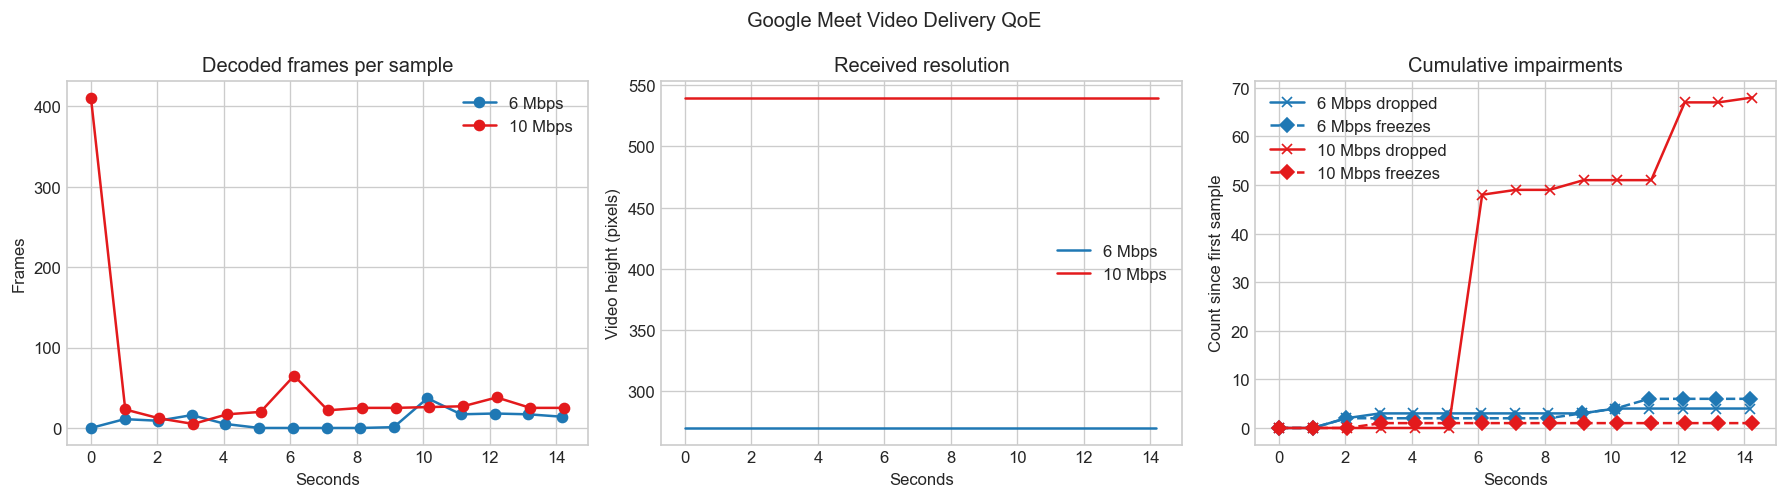

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=120)
for tier, run in runs.items():
    rows = run['meet']
    stats = [row['stats'] for row in rows]
    start = rows[0]['timestamp']
    seconds = [row['timestamp'] - start for row in rows]
    decoded = [s.get('frames_decoded_delta', 0) or 0 for s in stats]
    height = [s.get('frame_height', 0) or 0 for s in stats]
    dropped = [s['frames_dropped'] - stats[0]['frames_dropped'] for s in stats]
    freezes = [s['freeze_count'] - stats[0]['freeze_count'] for s in stats]
    axes[0].plot(seconds, decoded, marker='o', color=COLORS[tier], label=f'{tier} Mbps')
    axes[1].step(seconds, height, where='post', color=COLORS[tier], label=f'{tier} Mbps')
    axes[2].plot(seconds, dropped, marker='x', color=COLORS[tier], linestyle='-', label=f'{tier} Mbps dropped')
    axes[2].plot(seconds, freezes, marker='D', color=COLORS[tier], linestyle='--', label=f'{tier} Mbps freezes')
axes[0].set(title='Decoded frames per sample', xlabel='Seconds', ylabel='Frames')
axes[1].set(title='Received resolution', xlabel='Seconds', ylabel='Video height (pixels)')
axes[2].set(title='Cumulative impairments', xlabel='Seconds', ylabel='Count since first sample')
for ax in axes:
    ax.legend()
fig.suptitle('Google Meet Video Delivery QoE')
plt.tight_layout()
plt.show()